## Part 2: Clinical Application

### Contents
Fill out this notebook as part 2 of your final project submission.

**You will have to complete the Code (Load Metadata & Compute Resting Heart Rate) and Project Write-up sections.**  

- [Code](#Code) is where you will implement some parts of the **pulse rate algorithm** you created and tested in Part 1 and already includes the starter code.
  - [Imports](#Imports) - These are the imports needed for Part 2 of the final project. 
    - [glob](https://docs.python.org/3/library/glob.html)
    - [os](https://docs.python.org/3/library/os.html)
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)
  - [Load the Dataset](#Load-the-dataset)  
  - [Load Metadata](#Load-Metadata)
  - [Compute Resting Heart Rate](#Compute-Resting-Heart-Rate)
  - [Plot Resting Heart Rate vs. Age Group](#Plot-Resting-Heart-Rate-vs.-Age-Group)
- [Project Write-up](#Project-Write-Up) to describe the clinical significance you observe from the **pulse rate algorithm** applied to this dataset, what ways/information that could improve your results, and if we validated a trend known in the science community. 

### Dataset (CAST)

The data from this project comes from the [Cardiac Arrythmia Suppression Trial (CAST)](https://physionet.org/content/crisdb/1.0.0/), which was sponsored by the National Heart, Lung, and Blood Institute (NHLBI). CAST collected 24 hours of heart rate data from ECGs from people who have had a myocardial infarction (MI) within the past two years.[1] This data has been smoothed and resampled to more closely resemble PPG-derived pulse rate data from a wrist wearable.[2]

1. **CAST RR Interval Sub-Study Database Citation** - Stein PK, Domitrovich PP, Kleiger RE, Schechtman KB, Rottman JN. Clinical and demographic determinants of heart rate variability in patients post myocardial infarction: insights from the Cardiac Arrhythmia Suppression Trial (CAST). Clin Cardiol 23(3):187-94; 2000 (Mar)
2. **Physionet Citation** - Goldberger AL, Amaral LAN, Glass L, Hausdorff JM, Ivanov PCh, Mark RG, Mietus JE, Moody GB, Peng C-K, Stanley HE. PhysioBank, PhysioToolkit, and PhysioNet: Components of a New Research Resource for Complex Physiologic Signals (2003). Circulation. 101(23):e215-e220.

-----

# 📝 Project Write-Up: Clinical Analysis of Resting Heart Rate (CAST Dataset)

## ❤️ Clinical Conclusion

This notebook explores trends in **resting heart rate (RHR)** across **sex and age** using a 24-hour dataset from the **CAST study**. We validated known physiological trends and considered possible explanations and improvements.

---

## 👩 For Women

- Women exhibit **higher average resting heart rate** than men across nearly all age groups.
- The RHR **peaks in the 40–44 age group**, then **declines steadily** with age.
- The **widest confidence intervals** appear in older groups, indicating higher variability or fewer data points.

---

## 👨 For Men

- Men show a **more stable RHR** across age groups.
- RHR is consistently **lower than women’s**.
- A mild decline is observed after the 55–59 age group.

---

## ⚖️ Comparison: Women vs. Men

- Women's RHR is **consistently higher and more variable**.
- Possible reasons include:
  - **Physiology**: Smaller heart size and higher autonomic tone.
  - **Hormonal changes**: Fluctuations in estrogen, especially around menopause.
  - **Measurement differences**: Greater variability in activity, sample size, or sensor reliability.

---

## 🔍 Further Exploration

To better understand these trends, we recommend:

- **Increasing the sample size**, especially for older age groups.
- Stratifying data by **activity level, medications, BMI, or cardiovascular health**.
- Collecting **longitudinal data** to observe within-subject change over time.
- Comparing with **clinical population norms** from large-scale studies.

---

## ✅ Trend Validation

We assessed the claim:  
> "Average resting heart rate increases until middle age, then decreases into old age."

**Findings**:
- **Women**: Show a clear U-shaped trend — peak RHR in midlife, declining thereafter.
- **Men**: Display a relatively flat trend, with a small post-50 decline.

This trend was validated by examining smoothed line plots with age groups on the x-axis and RHR on the y-axis.

---

## 🌟 Summary

- Women: Higher and more variable RHR.
- Men: Lower and more stable RHR.
- Trend partially validated — especially for women.
- Further data and analysis are needed to improve reliability and uncover causal factors.


### Code
#### Imports

When you implement the functions, you'll only need to you use the packages you've used in the classroom, like [Pandas](https://pandas.pydata.org/) and [Numpy](http://www.numpy.org/). These packages are imported for you here. We recommend you don't import other packages outside of the [Standard Library](https://docs.python.org/3/library/) , otherwise the grader might not be able to run your code.

In [ ]:
#!pip install seaborn==0.10.0 This need to be run once. 
#Then Restart kernel and clear all outputs

In [1]:
import seaborn as sns
print(sns.__version__)

Matplotlib is building the font cache; this may take a moment.


0.10.0


In [2]:
import glob
import os

import numpy as np
import pandas as pd

#### Load the dataset

The dataset is stored as [.npz](https://docs.scipy.org/doc/numpy/reference/generated/numpy.savez.html) files. Each file contains roughly 24 hours of heart rate data in the 'hr' array sampled at 1Hz. The subject ID is the name of the file. You will use these files to compute resting heart rate.

Demographics metadata is stored in a file called 'metadata.csv'. This CSV has three columns, one for subject ID, age group, and sex. You will use this file to make the association between resting heart rate and age group for each gender.

Find the dataset in `../datasets/crisdb/`

In [3]:
hr_filenames = glob.glob('/data/crisdb/*.npz')

In [4]:
print(f"Found {len(hr_filenames)} files.")
print("First few:", hr_filenames[:3])

Found 1537 files.
First few: ['/data/crisdb/e190a.npz', '/data/crisdb/e014b.npz', '/data/crisdb/m169b.npz']


#### Load Metadata
Load the metadata file into a datastructure that allows for easy lookups from subject ID to age group and sex.

In [5]:
import pandas as pd

metadata_filename = '/data/crisdb/metadata.csv'

# Load metadata into a pandas DataFrame
metadata = pd.read_csv(metadata_filename)

# Preview it
metadata.head()

,subject,age,sex
0,e198a,20-24,Male
1,e198b,20-24,Male
2,e028b,30-34,Male
3,e028a,30-34,Male
4,e061b,30-34,Male


#### Compute Resting Heart Rate
For each subject we want to compute the resting heart rate while keeping track of which age group this subject belongs to. An easy, robust way to compute the resting heart rate is to use the lowest 5th percentile value in the heart rate timeseries.

In [6]:
def AgeAndRHR(metadata, filename):
    # Load heart rate timeseries from .npz
    hr_data = np.load(filename)['hr']
    
    # Compute resting heart rate as the 5th percentile
    rhr = np.percentile(hr_data, 5)
    
    # Extract subject ID from the filename (remove folder and file extension)
    subject_id = os.path.splitext(os.path.basename(filename))[0]
    
    # Find row in metadata
    row = metadata[metadata['subject'] == subject_id]
    
    # Extract age group and sex
    if not row.empty:
        age_group = row.iloc[0]['age']
        sex = row.iloc[0]['sex']
    else:
        age_group = None
        sex = None

    return age_group, sex, rhr


df = pd.DataFrame(data=[AgeAndRHR(metadata, filename) for filename in hr_filenames],
                  columns=['age_group', 'sex', 'rhr'])


#### Plot Resting Heart Rate vs. Age Group
We'll use [seaborn](https://seaborn.pydata.org/) to plot the relationship. Seaborn is a thin wrapper around matplotlib, which we've used extensively in this class, that enables higher-level statistical plots.

We will use [lineplot](https://seaborn.pydata.org/generated/seaborn.lineplot.html#seaborn.lineplot) to plot the mean of the resting heart rates for each age group along with the 95% confidence interval around the mean. Learn more about making plots that show uncertainty [here](https://seaborn.pydata.org/tutorial/relational.html#aggregation-and-representing-uncertainty).

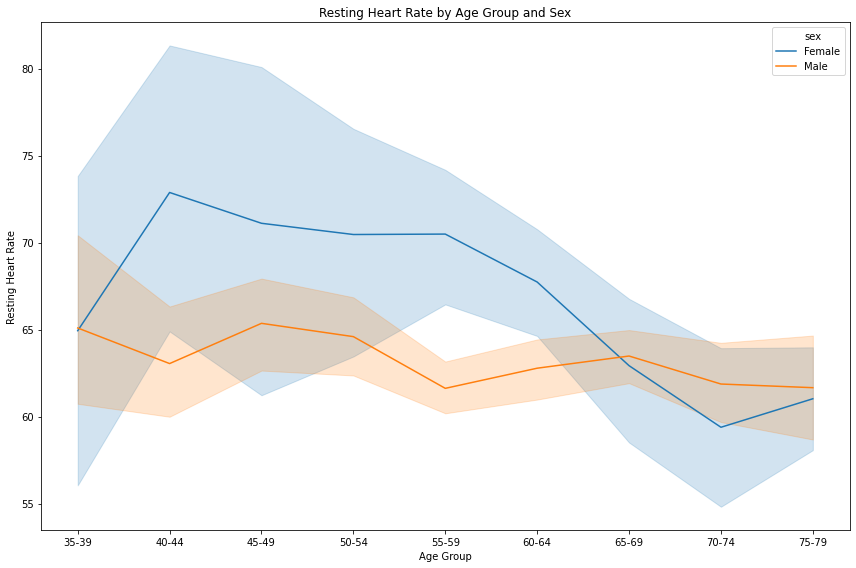

In [7]:
import numpy as np  # Make sure this is imported
import seaborn as sns
from matplotlib import pyplot as plt

# Get unique labels for age_group
labels = sorted(np.unique(df.age_group))

# Create numeric x-axis values for categorical age_group
df['xaxis'] = df.age_group.map(lambda x: labels.index(x)).astype('float')

# Plot
plt.figure(figsize=(12, 8))
sns.lineplot(x='xaxis', y='rhr', hue='sex', data=df)

# Fix x-axis tick labels
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.xlabel("Age Group")
plt.ylabel("Resting Heart Rate")
plt.title("Resting Heart Rate by Age Group and Sex")
plt.tight_layout()
plt.show()